# Install requirements


In [65]:
pip install torch torchvision matplotlib numpy SimpleITK ipywidgets jupyterlab_widgets opencv-python --extra-index-url https://download.pytorch.org/whl/cu117

Looking in indexes: https://pypi.org/simple, https://download.pytorch.org/whl/cu117
Note: you may need to restart the kernel to use updated packages.


# Imports


In [66]:
import os
import random
import time
from datetime import datetime

import matplotlib.pyplot as plt
import matplotlib.image 
import numpy as np
import SimpleITK as sitk
import torch
import torch.nn as nn
import torchvision.transforms
import torchvision.transforms as T
from torch.utils.data import DataLoader, Dataset, random_split
from torchvision import transforms
from tqdm import tqdm
from torchvision.utils import save_image
from PIL import Image
import cv2


# Setup up some config


In [67]:
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
PIN_MEMORY = True if DEVICE == "cuda" else False

DATASET_PATH = "C:\\bratsdata"
DATASET_PROCESSED_PATH = "C:\\bratsdata_processed_2d"
MODEL_FOLDER_PATH = "./output_models"
MODEL_PATH = (
    MODEL_FOLDER_PATH + "/" + "unet_model" + str(datetime.now().microsecond) + ".pt"
)

CHECKPOINT_PATH = "checkpoint.pt"

INPUT_CHANNELS = 4
OUTPUT_CHANNELS = 4

IMAGE_WIDTH = 128
IMAGE_HEIGHT = 128

BATCH_SIZE = 2
LEARNING_RATE = 0.0001  # 0.0001
NUM_EPOCHS = 20

TEST_VALIDATION_SPLIT = 0.2
SEED = 126728


# Prepare the paths


In [68]:
class Paths:
    def __init__(self, root_path):
        self.root_path = root_path
        self.file_list = os.listdir(root_path)

    def get_file_path_list(self, mri_type="t1"):
        path_list = []
        mask_list = []
        for index in range(len(self.file_list)):
            path_list.append(self.get_file_path(index, mri_type))
            mask_list.append(self.get_file_path(index, mask=True))
        return np.array(path_list), np.array(mask_list)

    def get_file_path_list_multi_channel(self, discard_channels=[]):
        mri_type_list = ["t1", "t1ce", "t2", "flair"]
        path_list = []
        mask_list = []
        for index in range(len(self.file_list)):
            channels = []
            for mri_type in mri_type_list:
                channels.append(self.get_file_path(index, mri_type))
            path_list.append(channels)
            mask_list.append(self.get_file_path(index, mask=True))
        return np.array(path_list), np.array(mask_list)

    def get_file_path(self, index: int, mri_type="t1", mask: bool = False):
        name = (
            self.__get_label_image_name(index)
            if mask
            else self.__get_image_name(index, mri_type)
        )
        return os.path.join(self.root_path, self.file_list[index], name)

    def __get_image_name(self, index: int, mri_type: str):
        return self.file_list[index] + "_" + mri_type + ".nii.gz"

    def __get_label_image_name(self, index: int):
        return self.file_list[index] + "_seg.nii.gz"


# Preprocess Data

1. Shrink image size to 128x128x128
2. Normalize images between 0 and 1
3. Save 3D images as 2D Slices in PNG on disk

In [80]:
def __get_numpy_array(path):
    return sitk.GetArrayFromImage(sitk.ReadImage(path, sitk.sitkInt16))


def __reshape_slices(obj):
    return obj[14:142, ...]


def __resize_image(obj):
    return torchvision.transforms.Resize(size=(IMAGE_WIDTH, IMAGE_HEIGHT))(obj)


def preprocess_image(img):
    processed_image = torch.from_numpy(img).to(torch.float)
    # processed_image = torch.nn.functional.normalize(processed_image)
    processed_image = __reshape_slices(processed_image)
    processed_image = __resize_image(processed_image)
    processed_image = processed_image.to(torch.float)
    return processed_image


def preprocess_label(label):
    label[label == 4] = 3
    mask = __reshape_slices(label)
    new_mask = torch.from_numpy(mask)
    new_mask = new_mask.to(torch.float)
    # new_mask  = torch.nn.functional.normalize(new_mask)
    new_mask = __resize_image(new_mask)
    return new_mask


def save_img_slices(img, path, vmin=None, vmax=None):
    for i in range(img.shape[0]):
        folder_path = DATASET_PROCESSED_PATH + "\\" + path.split("\\")[2] + "\\"
        if not os.path.exists(folder_path):
            os.makedirs(folder_path)

        save_path = (
            DATASET_PROCESSED_PATH
            + "\\"
            + path.split("\\")[2]
            + "\\"
            + path.split("\\")[3].split(".")[0]
            + f"_{i}.png"
        )
        # sitk.WriteImage(sitk.GetImageFromArray(img), save_path)
        # save_image(img[i], save_path)
        # Image.fromarray(img[i].numpy()).convert("L").save(save_path)
        # cv2.imwrite(save_path, img[i].numpy())
        matplotlib.image.imsave(save_path, img[i],vmin=vmin,vmax=vmax)


if not os.path.exists(DATASET_PROCESSED_PATH):
    os.mkdir(DATASET_PROCESSED_PATH)

image_paths, label_paths = Paths(DATASET_PATH).get_file_path_list_multi_channel()
for imgs_path, label_path in zip(image_paths, label_paths):
    for single_img_path in imgs_path:
        img = preprocess_image(__get_numpy_array(single_img_path))
        save_img_slices(img, single_img_path)

    y = preprocess_label(__get_numpy_array(label_path))
    save_img_slices(y, label_path, 0, 3)


KeyboardInterrupt: 

# Load data to verify

BraTS2021_00000_seg_45.png


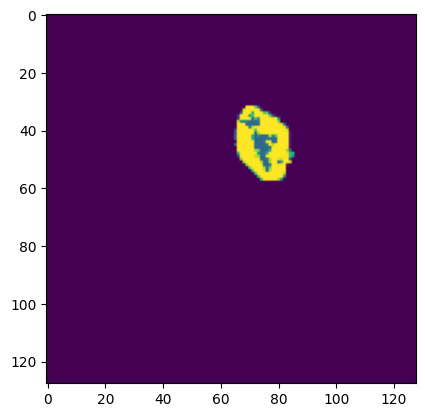

In [81]:
processed_file_paths = os.listdir(DATASET_PROCESSED_PATH)
files = os.listdir(DATASET_PROCESSED_PATH + "\\" + processed_file_paths[0])
#print(files)
img = plt.imread(DATASET_PROCESSED_PATH + "\\" + processed_file_paths[0] + "\\" + files[196])
#img = loaded["img"]
#label = loaded["label"]
#label = label.astype(float)
#label[label == 0] = np.nan
print(files[196])
plt.imshow(img, cmap="gray")
#plt.imshow(label[59], alpha=0.3, cmap="viridis")


# Setup the Dataset

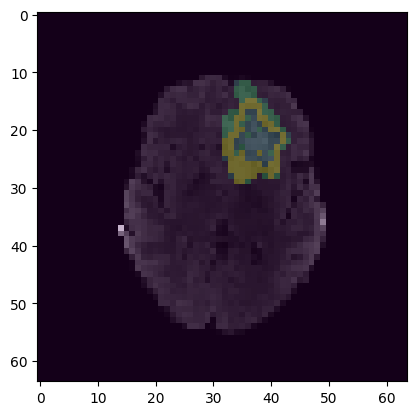

In [ ]:
class BratsDataset(Dataset):
    def __init__(self, paths, transforms=None):
        super().__init__()
        self.paths = paths
        self.transforms = transforms

    def __getitem__(self, index):
        loaded = np.load(self.paths[index])
        img, label = torch.from_numpy(loaded["img"]), torch.from_numpy(loaded["label"])
        if self.transforms != None:
            # Apply transforms also on label because label is an image mask
            img, label = self.transforms(img), self.transforms(label)
        return img, label

    def __len__(self):
        return len(self.paths)
# file_paths = [
#     DATASET_PROCESSED_PATH + "\\" + single_path
#     for single_path in os.listdir(DATASET_PROCESSED_PATH)
# ]
# dataset = BratsDataset(file_paths)
# img, label = next(iter(dataset))
# plt.imshow(img[3][59], cmap="gray")
# plt.imshow(label[59], alpha=0.3, cmap="viridis")


# Setup the model

In [ ]:
class InConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super(InConv, self).__init__()
        self.conv = DoubleConv(in_ch, out_ch)

    def forward(self, x):
        x = self.conv(x)
        return x


class Down(nn.Module):
    def __init__(self, in_ch, out_ch):
        super(Down, self).__init__()
        self.mpconv = nn.Sequential(nn.MaxPool3d(2, 2), DoubleConv(in_ch, out_ch))

    def forward(self, x):
        x = self.mpconv(x)
        return x


class OutConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super(OutConv, self).__init__()
        self.conv = nn.Conv3d(in_ch, out_ch, 1)

    def forward(self, x):
        x = self.conv(x)
        return x


class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super(DoubleConv, self).__init__()
        self.conv = nn.Sequential(
            nn.Conv3d(in_ch, out_ch, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm3d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv3d(out_ch, out_ch, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm3d(out_ch),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        x = self.conv(x)
        return x


class Up(nn.Module):
    def __init__(self, in_ch, skip_ch, out_ch):
        super(Up, self).__init__()
        self.up = nn.ConvTranspose3d(in_ch, in_ch, kernel_size=2, stride=2)
        self.conv = DoubleConv(in_ch + skip_ch, out_ch)

    def forward(self, x1, x2):
        x1 = self.up(x1)
        x = torch.cat([x2, x1], dim=1)
        x = self.conv(x)
        return x


class UNet(nn.Module):
    def __init__(self, in_channels, out_channels, features=[16, 32, 64, 96]):
        super(UNet, self).__init__()
        # features = [32, 64, 128, 256]
        # features = [64, 128, 256, 512]
        features[:] = [x // 2 for x in features]

        self.inc = InConv(in_channels, features[0])
        self.down1 = Down(features[0], features[1])
        self.down2 = Down(features[1], features[2])
        self.down3 = Down(features[2], features[3])
        self.down4 = Down(features[3], features[3])

        self.up1 = Up(features[3], features[3], features[2])
        self.up2 = Up(features[2], features[2], features[1])
        self.up3 = Up(features[1], features[1], features[0])
        self.up4 = Up(features[0], features[0], features[0])
        self.outc = OutConv(features[0], out_channels)

    def forward(self, x):
        x1 = self.inc(x)
        x2 = self.down1(x1)
        x3 = self.down2(x2)
        x4 = self.down3(x3)
        x5 = self.down4(x4)

        x = self.up1(x5, x4)
        x = self.up2(x, x3)
        x = self.up3(x, x2)
        x = self.up4(x, x1)
        x = self.outc(x)
        return x


# Setup everything for training the model

In [ ]:
file_paths = [
    DATASET_PROCESSED_PATH + "\\" + single_path
    for single_path in os.listdir(DATASET_PROCESSED_PATH)
]

transformations = nn.Sequential(
    transforms.RandomHorizontalFlip(0.5),
    transforms.RandomVerticalFlip(0.5),
    transforms.RandomRotation(90),
)

dataset = BratsDataset(file_paths)

train_dataset, test_dataset = random_split(
    dataset, [0.8, 0.2], torch.Generator().manual_seed(42)
)
train_loader = DataLoader(
    train_dataset,
    shuffle=True,
    batch_size=BATCH_SIZE,
    pin_memory=False,
    num_workers=os.cpu_count(),
)
test_loader = DataLoader(
    test_dataset,
    shuffle=False,
    batch_size=BATCH_SIZE,
    pin_memory=False,
    # num_workers=os.cpu_count(),
)

model = UNet(
    in_channels=INPUT_CHANNELS,
    out_channels=OUTPUT_CHANNELS,
    features=[8, 16, 32, 64],
).to(DEVICE)

optimizer = torch.optim.SGD(model.parameters(), lr=LEARNING_RATE, momentum=0.9)
criterion = nn.CrossEntropyLoss()

img, label = next(iter(train_loader))
img.shape


RuntimeError: DataLoader worker (pid(s) 4808, 14268, 7996, 10808, 2496, 16920, 17536, 12584, 6300, 6480, 15204, 12168, 12508, 13792, 2316, 20328) exited unexpectedly

# Train

In [ ]:
print(f"[INFO] Start training network...")
start_time = time.time()
model.train()
progess_bar = tqdm(range(NUM_EPOCHS), leave=True, unit="epoch")
# acc = torchmetrics.Accuracy(task="multilabel", num_labels=4).to(config.DEVICE)
for epoch in progess_bar:
    progess_bar.set_description(f"[Epoch {epoch+1}]")
    running_loss = 0.0
    for inputs, labels in tqdm(
        train_loader, unit="batches", desc=f"[Epoch {epoch+1}|Train]"
    ):
        inputs = inputs.to(DEVICE)
        labels = labels.to(DEVICE)

        outputs = model(inputs)
        loss = criterion(outputs, labels)

        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
    print(f"[Epoch {epoch + 1}|Result] Loss: {running_loss / len(train_loader):.4f}")

    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for inputs, labels in test_loader:
            # Move the inputs and labels to the specified device
            inputs = inputs.to(DEVICE)
            labels = labels.to(DEVICE)
            # Forward pass
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            val_loss += loss.item()
    print(f"Epoch {epoch + 1} Val Loss: {val_loss / len(test_loader):.4f}")

torch.save(model.state_dict(), MODEL_PATH)


[INFO] Start training network...










[Epoch 1|Train]:   0%|          | 0/501 [00:11<?, ?batches/s]
[Epoch 1]:   0%|          | 0/20 [00:11<?, ?epoch/s]


RuntimeError: DataLoader worker (pid(s) 10344, 11988, 17704, 12604, 18400, 15068, 15680, 19908, 9956, 10172, 6636, 13612, 13604, 3352, 12048, 6792) exited unexpectedly